# CYPLAN 101 Final Project

## Group 5 (Kayleen Nguyen, James Dinh)

This notebook visualizes 2 datasets from Berkeley's Open Data Portal to determine the relationship between auto/pedestrian collisions with pothole reports.

In [14]:
# --- Top Level pip code cell ---
%pip install -r ../requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import re

# Geocoding
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

In [5]:
collisions = pd.read_csv(
  '../data/processed/CLEANED-Street Story Reports - BERKELEY (City) - 10_30_2025.csv',
  skiprows=1,
  on_bad_lines='warn',
)
print(collisions.shape)
print(collisions["crash/near-miss mode"].unique())
collisions.head()

(286, 28)
[nan 'bike' 'wheelchair' 'walk' 'ride' 'other' 'scooter']


,OBJECTID,type,crash/near-miss date,crash/near-miss mode,crash/near-miss time of day,mode involved,e-scooter involved,Was anyone injured?,crash cause,crash narrative,...,e-bike,e-scooter,improvement,improvement narrative,address,report date,latitude,longitude,type.1,coordinates
0,1,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2018/10/01,37.85210642,-122.266374,polyline,"[[-122.26684570338,37.855135282701],[-122.2659..."
1,26,unsafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2018/10/01,37.86722269,-122.263246,polyline,"[[-122.263111999632,37.865621999652],[-122.263..."
2,27,nearMiss,10/11/2018,bike,night,driver,NaN,none,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2018/10/01,37.85584561,-122.262377,polyline,"[[-122.262382999711,37.8557790001916],[-122.26..."
3,28,nearMiss,10/11/2018,bike,night,driver,NaN,none,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2018/10/01,37.8558611,-122.262323,polyline,"[[-122.262334000205,37.8558380002484],[-122.26..."
4,39,nearMiss,08/2018,wheelchair,day,driver,NaN,none,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2018/10/01,37.86786842,-122.265686,polyline,"[[-122.265690000106,37.8679399998569],[-122.26..."


In [6]:
collisions["latitude"] = pd.to_numeric(collisions["latitude"], errors='coerce')
collisions["latitude"].dtype

dtype('float64')

In [7]:
potholes = pd.read_csv('../data/processed/CLEANED-311_Cases_-_COB_20251109 - Potholes.csv')
print(collisions.shape)
potholes.head()

(286, 28)


,Case_ID,Date_Opened,Case_Status,Date_Closed,Request_Category,Request_SubCategory,Request_Detail,Object_Type,APN,Street_Address,City,State,Neighborhood,Latitude,Longitude,Location
0,"121,000,736,207",2019 Dec 09 10:21:00 AM,Closed,2019 Dec 11 07:45:00 AM,"Streets, Utilities, and Transportation",Sidewalk/Street Maintenance,Potholes,Property,NaN,"Intersection of Shattuck and Derby, BERKELEY, CA",Berkeley,CA,Berkeley,NaN,NaN,NaN
1,"121,000,736,099",2019 Dec 07 02:21:00 PM,Closed,2019 Dec 11 07:47:00 AM,"Streets, Utilities, and Transportation",Sidewalk/Street Maintenance,Potholes,Property,056 191902800,2425 ACTON ST,Berkeley,CA,Berkeley,37.862836,-122.282839,"(37.86283611, -122.28283948)"
2,"121,000,751,284",2020 Feb 14 03:12:00 PM,Closed,2020 Feb 21 11:31:00 AM,"Streets, Utilities, and Transportation",Sidewalk/Street Maintenance,Potholes,Property,NaN,"Intersection of 8th and Cedar, BERKELEY, CA",Berkeley,CA,Berkeley,NaN,NaN,NaN
3,"121,000,750,546",2020 Feb 11 03:53:00 PM,Closed,2020 Feb 21 11:21:00 AM,"Streets, Utilities, and Transportation",Sidewalk/Street Maintenance,Potholes,Property,NaN,"Intersection of Euclid and Marin, BERKELEY, CA",Berkeley,CA,Berkeley,NaN,NaN,NaN
4,"121,000,736,098",2019 Dec 07 02:19:00 PM,Closed,2019 Dec 11 07:46:00 AM,"Streets, Utilities, and Transportation",Sidewalk/Street Maintenance,Potholes,Property,NaN,"Intersection of Acton and Channing, BERKELEY, CA",Berkeley,CA,Berkeley,NaN,NaN,NaN


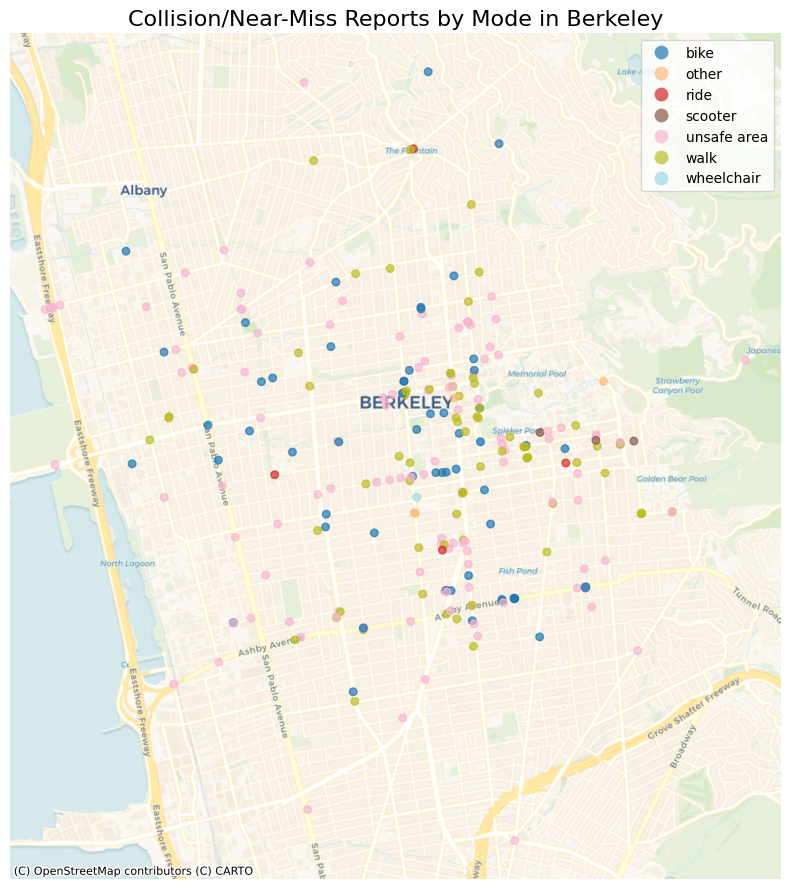

In [8]:
# Drop rows with NaN values in 'latitude' or 'longitude' to ensure valid points
collisions_cleaned = collisions.dropna(subset=['latitude', 'longitude']).copy()
collisions_filtered = collisions_cleaned[collisions_cleaned['type'] != 'positive'].copy()

gdf_collisions = gpd.GeoDataFrame(
    collisions_filtered,
    geometry=gpd.points_from_xy(collisions_filtered.longitude, collisions_filtered.latitude)
)

# Set the Coordinate Reference System (CRS) to WGS84 (latitude/longitude)
gdf_collisions = gdf_collisions.set_crs("EPSG:4326", allow_override=True)

# Reproject to Web Mercator for compatibility with contextily basemaps
gdf_collisions = gdf_collisions.to_crs("EPSG:3857")

gdf_collisions['crash/near-miss mode'] = gdf_collisions['crash/near-miss mode'].fillna('unsafe area')

fig, ax = plt.subplots(1, 1, figsize=(12, 9))

gdf_collisions.plot(
    ax=ax,
    column='crash/near-miss mode',
    legend=True,
    markersize=30,
    cmap='tab20',
    alpha=0.7
)

cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)

ax.set_title('Collision/Near-Miss Reports by Mode in Berkeley', fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

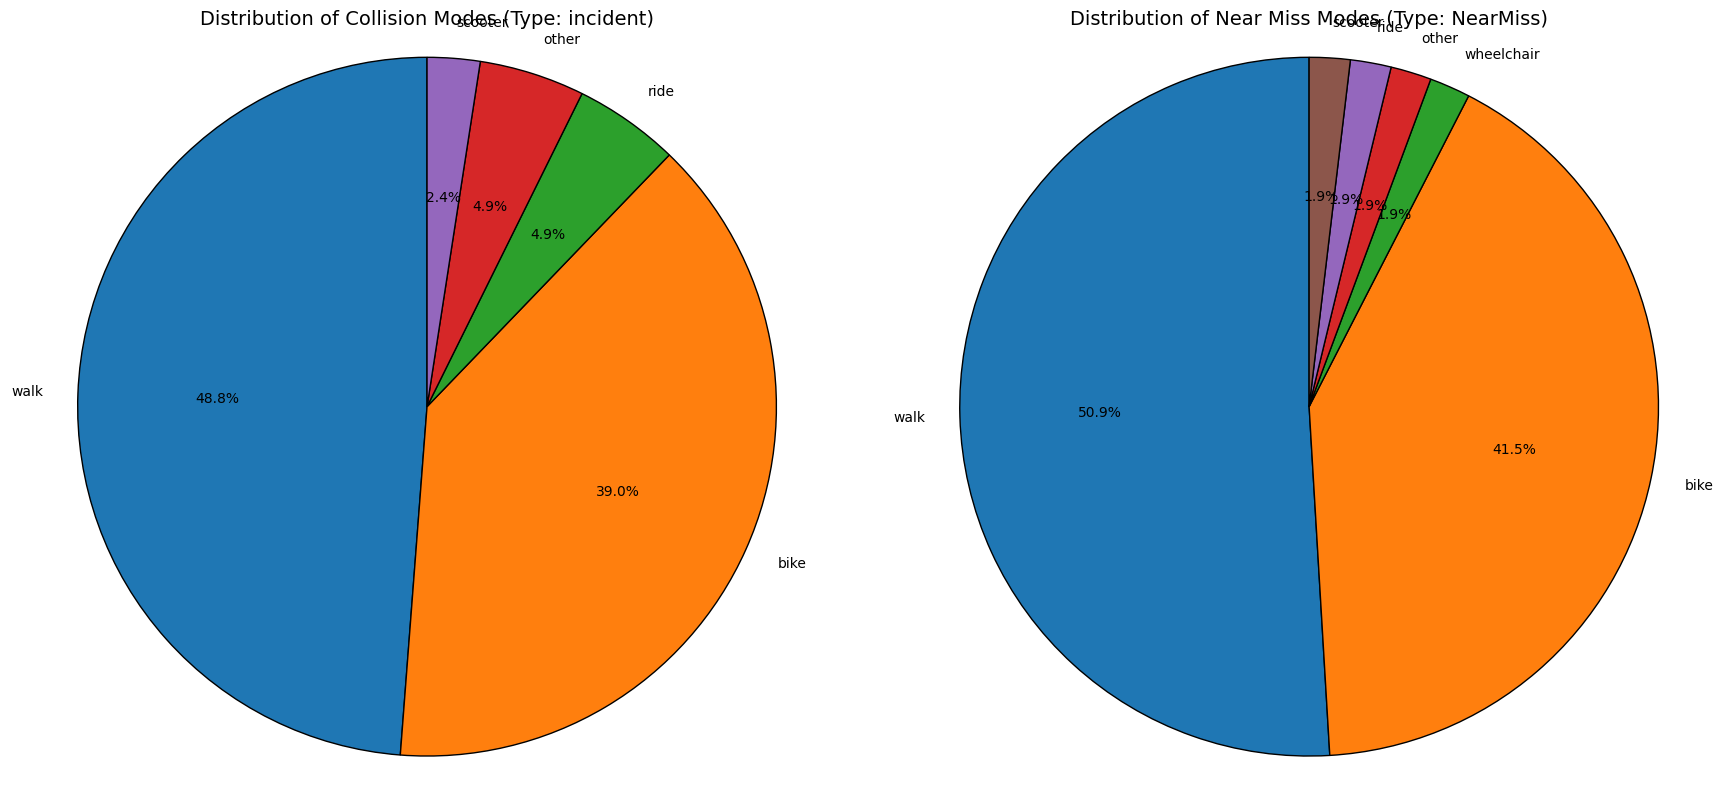

In [9]:
#  --- Plot Pie Chart for Modes of Collisions/Near Misses
# Filter for 'unsafe' type
collisions_data = gdf_collisions[gdf_collisions['type'] == 'incident']
collision_modes = collisions_data['crash/near-miss mode'].value_counts()

# Filter for 'nearMiss' type
near_miss_data = gdf_collisions[gdf_collisions['type'] == 'nearMiss']
near_miss_modes = near_miss_data['crash/near-miss mode'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Pie Chart for Collisions (type='unsafe')
if not collision_modes.empty:
    axes[0].pie(collision_modes, labels=collision_modes.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
    axes[0].set_title('Distribution of Collision Modes (Type: incident)', fontsize=14)
    axes[0].axis('equal')
else:
    axes[0].set_title('No Collision Data (Type: Unsafe) Available', fontsize=14)
    axes[0].text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)

# Pie Chart for Near Misses (type='nearMiss')
if not near_miss_modes.empty:
    axes[1].pie(near_miss_modes, labels=near_miss_modes.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
    axes[1].set_title('Distribution of Near Miss Modes (Type: NearMiss)', fontsize=14)
    axes[1].axis('equal')
else:
    axes[1].set_title('No Near Miss Data (Type: NearMiss) Available', fontsize=14)
    axes[1].text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

In [10]:
# --- Geocoding (for later) ---
# def normalize_intersection(address):
#     if isinstance(address, str) and "Intersection of" in address:
#         # Extract street names and format with '&'
#         match = re.search(r'Intersection of (.+?) and (.+)', address, re.IGNORECASE)
#         if match:
#             street1, street2 = match.groups()
#             return f"{street1.strip()} & {street2.strip()}, Berkeley, CA"
#     return address

# geolocator = Nominatim(user_agent="berkeley_potholes_geocoder") # Replace 'my_geocoder' with a unique app name
# geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1, max_retries=3, error_wait_seconds=5)

# def geocode_address(address):
#     if pd.isna(address):
#         return None, None
#     try:
#         location = geocode(address + ", Berkeley, CA")
#         if location:
#             return location.latitude, location.longitude
#     except Exception as e:
#         print(f"Error geocoding {address}: {e}")
#     return None, None

# missing_coords_potholes = potholes[potholes['Latitude'].isna() & potholes['Longitude'].isna()].copy()
# missing_coords_potholes['normalized_address'] = missing_coords_potholes['Street_Address'].apply(normalize_intersection)
# missing_coords_potholes[['geocoded_latitude', 'geocoded_longitude']] = (
#     missing_coords_potholes['normalized_address']
#     .apply(lambda x: pd.Series(geocode_address(x)))
# )

# print("\nExample of geocoded addresses:")
# print(missing_coords_potholes[['Street_Address', 'geocoded_latitude', 'geocoded_longitude']].head())

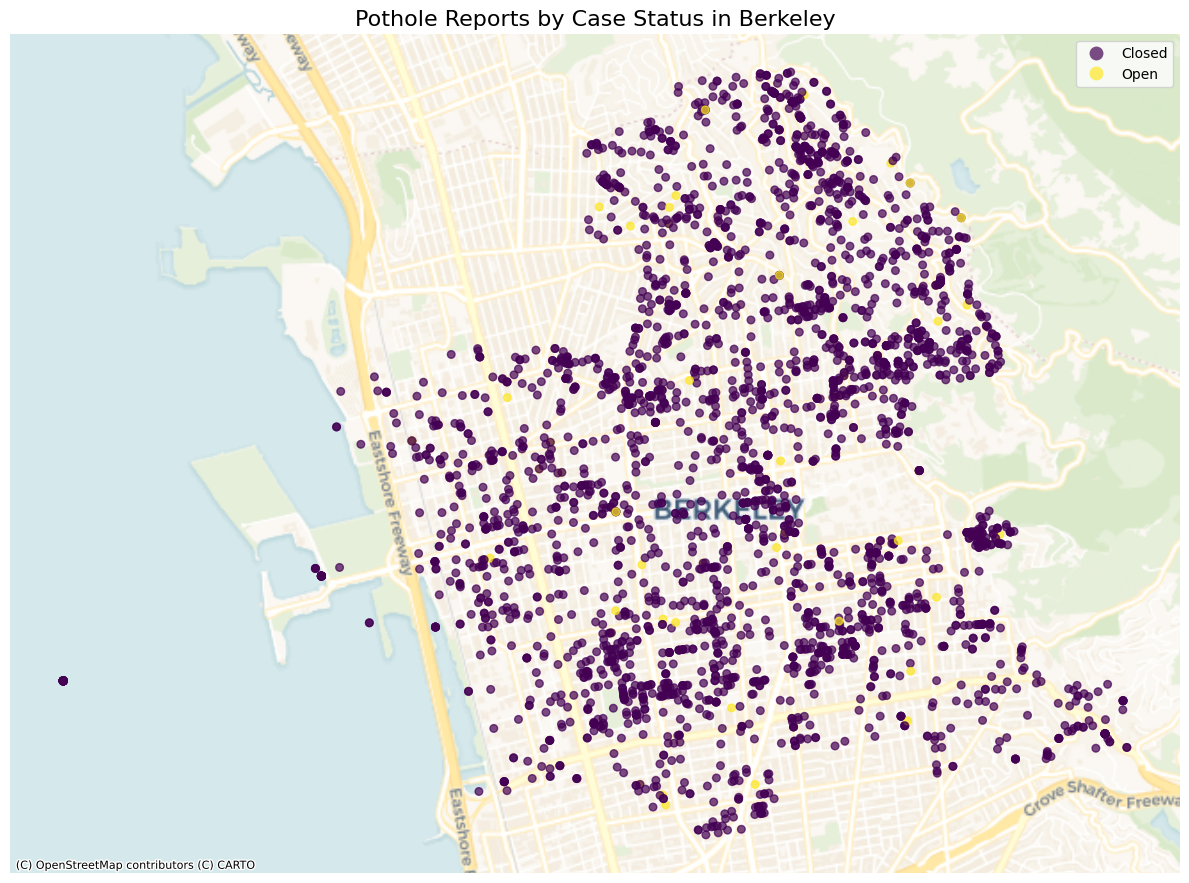

In [11]:
# --- Plot Pothole Reports in Berkeley ---

# Drop rows with NaN values in 'Latitude' or 'Longitude' to ensure valid points for plotting
potholes_cleaned = potholes.dropna(subset=['Latitude', 'Longitude']).copy()

gdf_potholes = gpd.GeoDataFrame(
    potholes_cleaned,
    geometry=gpd.points_from_xy(potholes_cleaned.Longitude, potholes_cleaned.Latitude)
)

# Set the Coordinate Reference System (CRS) to WGS84 (latitude/longitude)
gdf_potholes = gdf_potholes.set_crs("EPSG:4326", allow_override=True)

# Reproject to Web Mercator for compatibility with contextily basemaps
gdf_potholes = gdf_potholes.to_crs("EPSG:3857")

# Handle NaN values in 'Case_Status' for plotting by filling them with 'Unknown'
gdf_potholes['Case_Status'] = gdf_potholes['Case_Status'].fillna('Unknown')

fig, ax = plt.subplots(1, 1, figsize=(12, 9))

gdf_potholes.plot(
    ax=ax,
    column='Case_Status',
    legend=True,
    markersize=30,
    cmap='viridis',
    alpha=0.7
)

cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)

ax.set_title('Pothole Reports by Case Status in Berkeley', fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

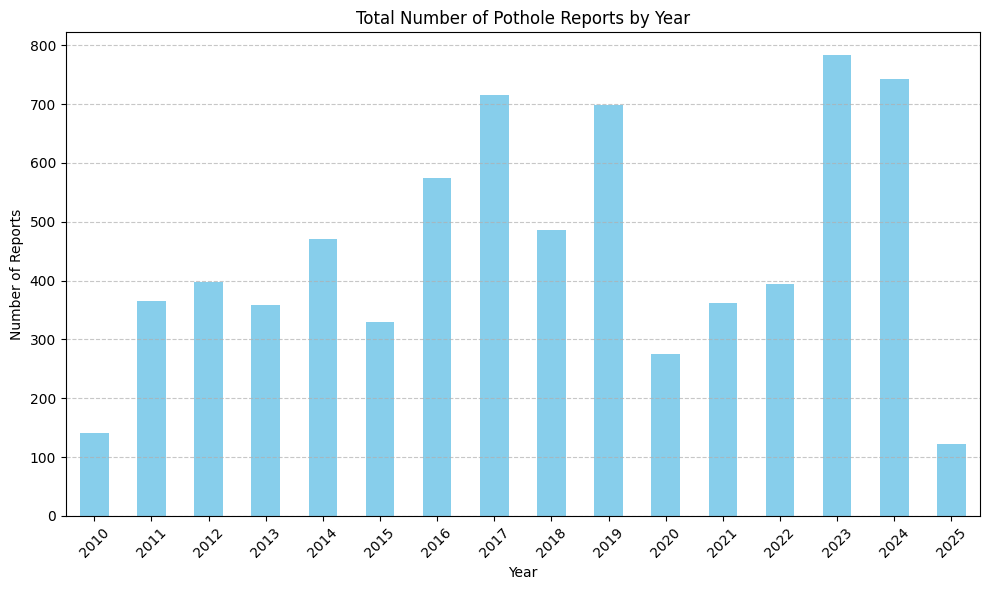

Reports by year:
year
2010    141
2011    366
2012    397
2013    359
2014    470
Name: count, dtype: int64


In [12]:
# Expand Date_Opened row with year column to plot reports by year
potholes['Date_Opened'] = pd.to_datetime(potholes['Date_Opened'], format='%Y %b %d %I:%M:%S %p', errors='coerce')

potholes['year'] = potholes['Date_Opened'].dt.year

reports_by_year = potholes['year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
reports_by_year.plot(kind='bar', color='skyblue')
plt.title('Total Number of Pothole Reports by Year')
plt.xlabel('Year')
plt.ylabel('Number of Reports')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Reports by year:")
print(reports_by_year.head())